In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
from datetime import datetime
import glob

In [65]:
data_files = glob.glob('../data/*.csv')
all_data = []

for file in data_files:
    df = pd.read_csv(file)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    all_data.append(df)

combined_data = pd.concat(all_data)

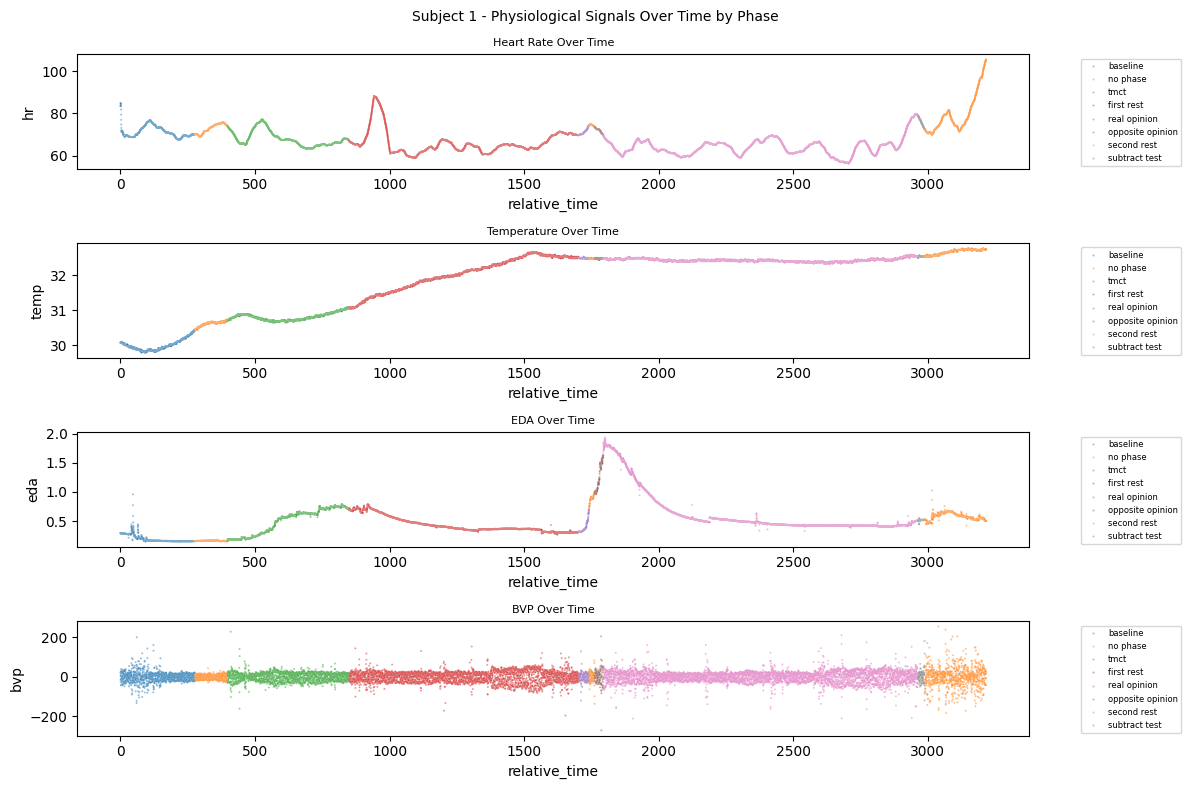

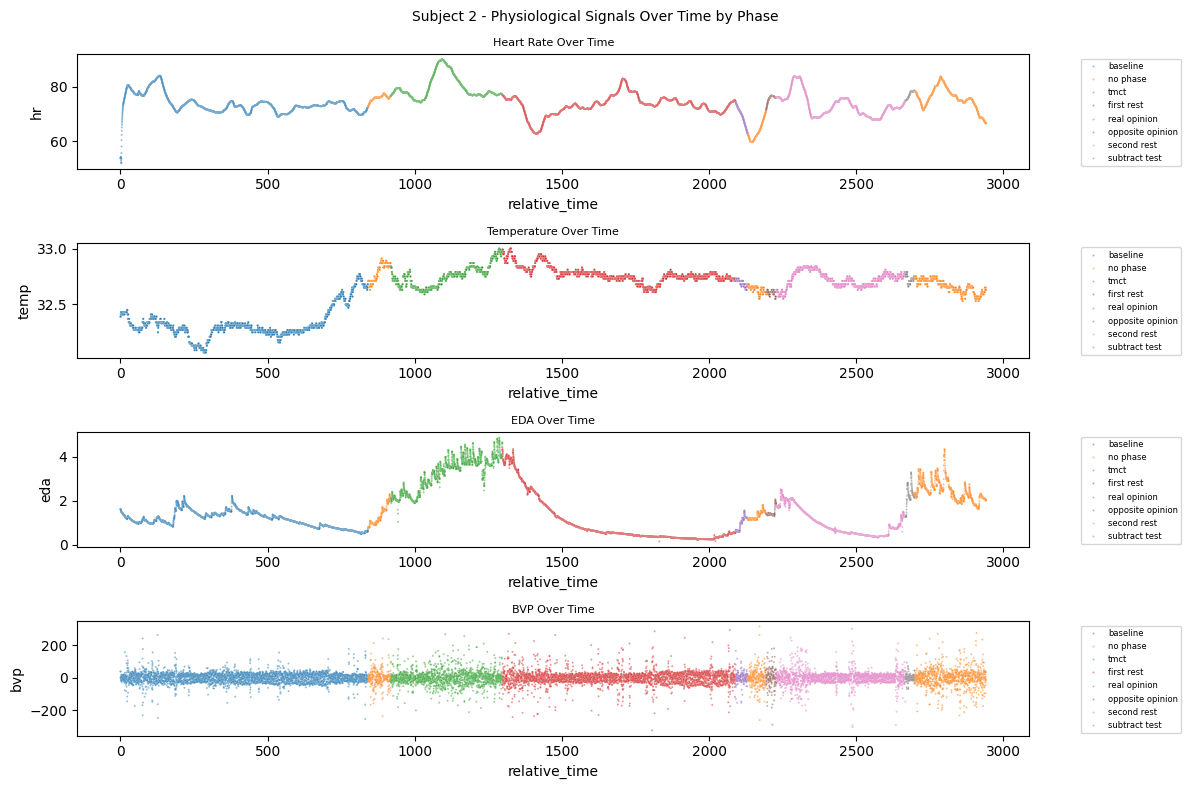

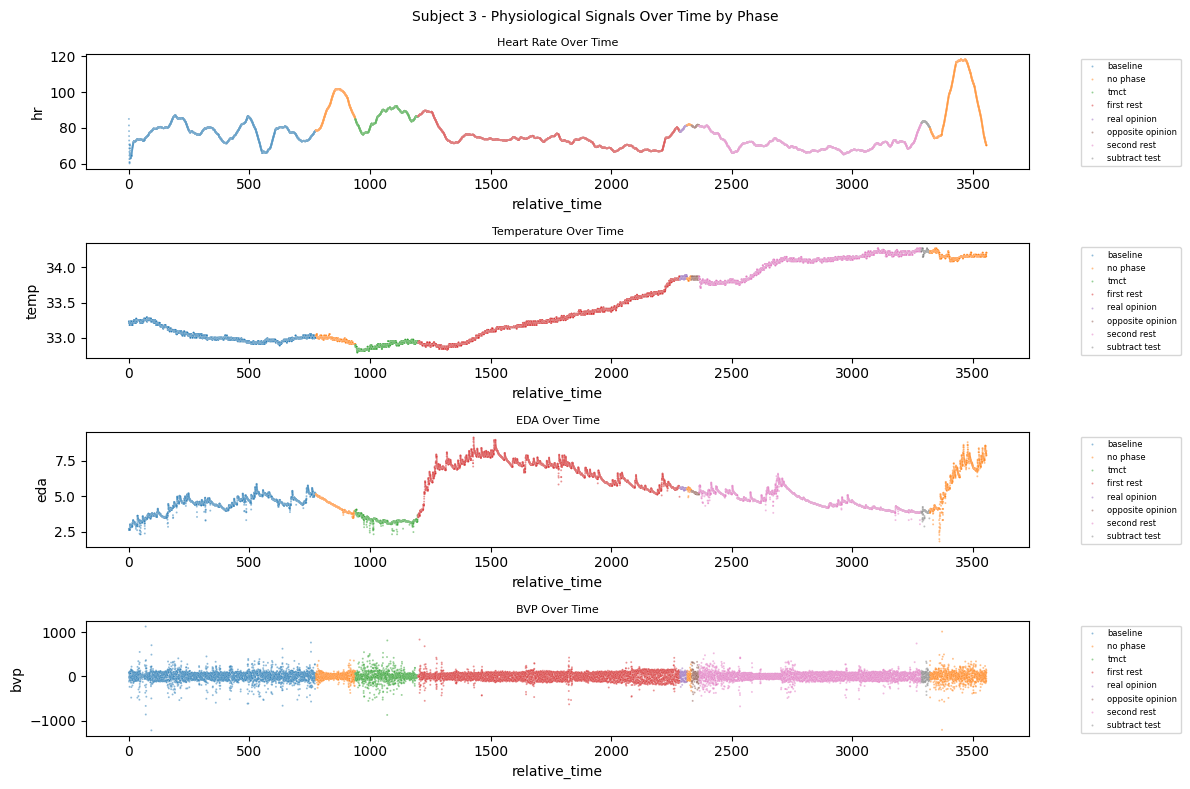

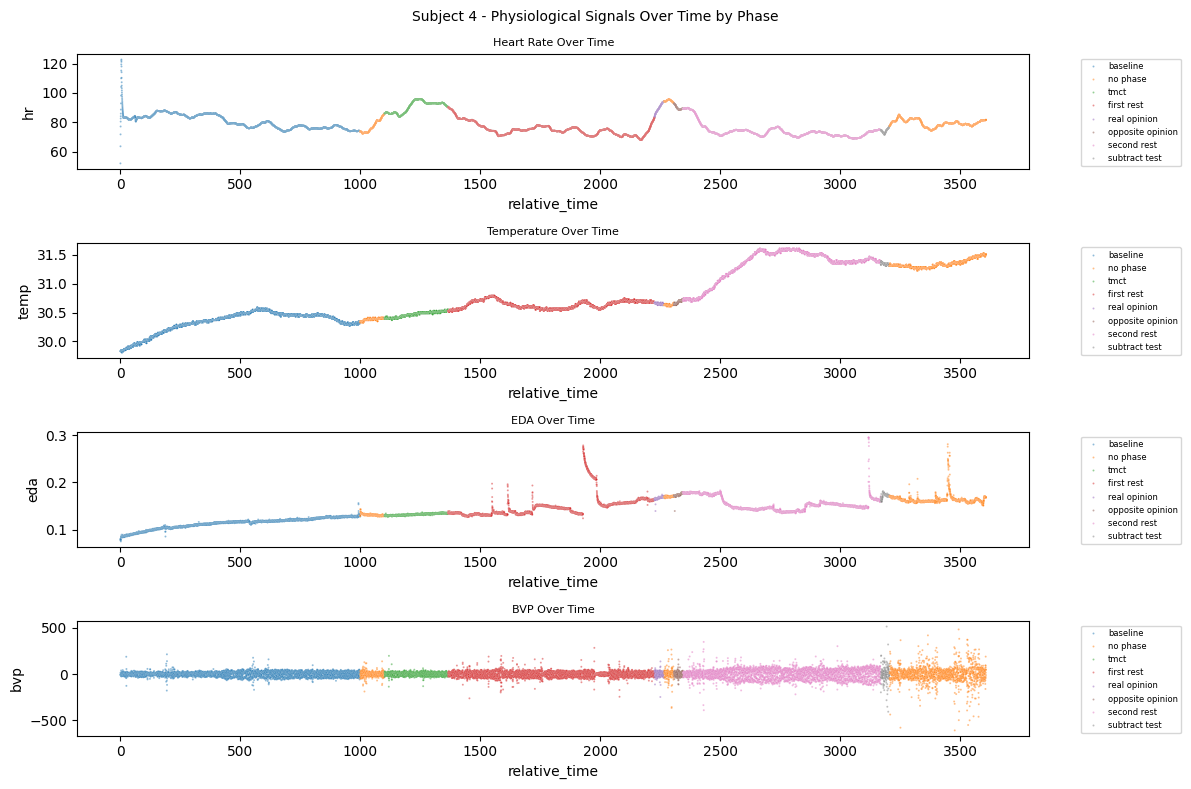

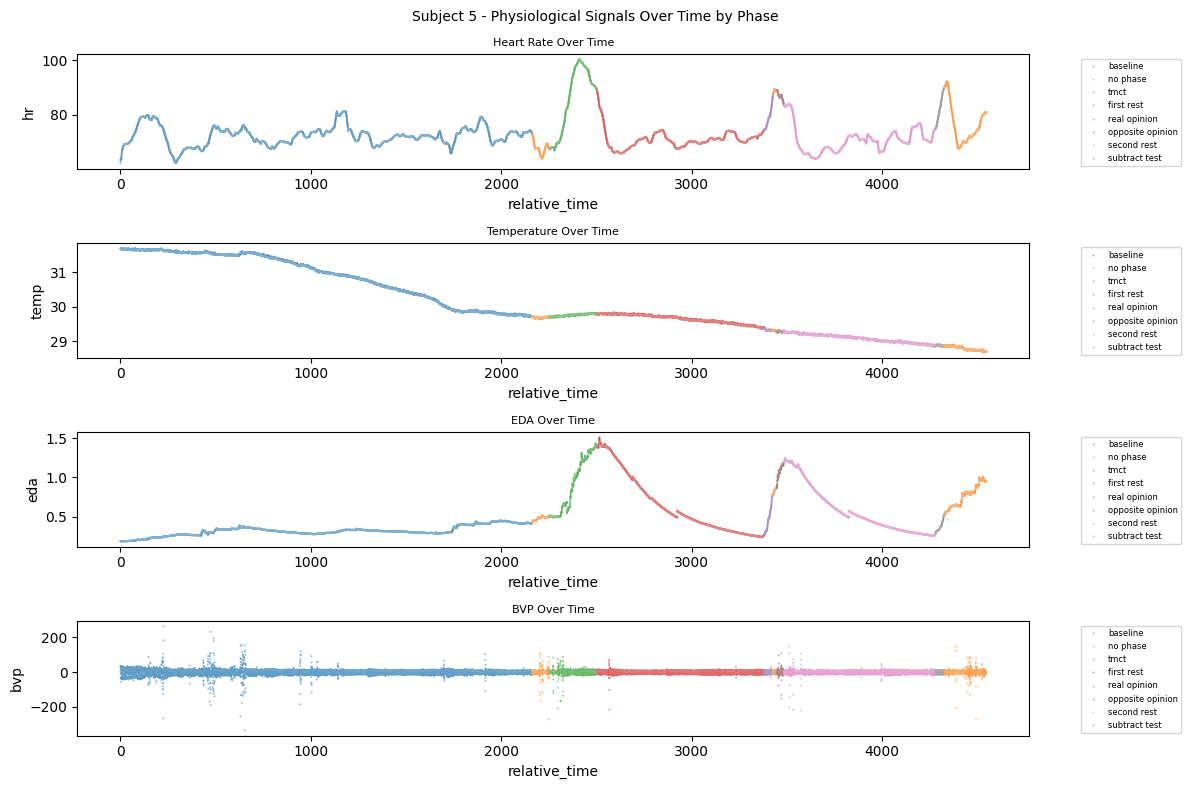

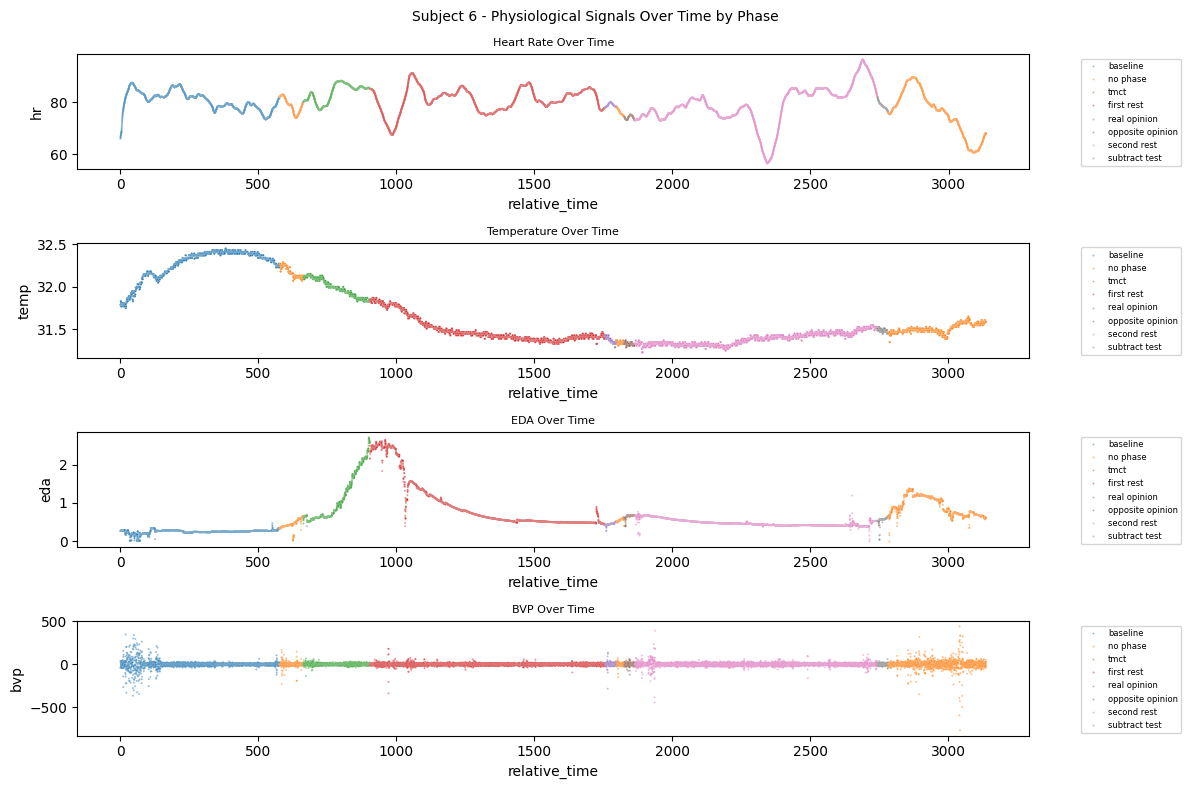

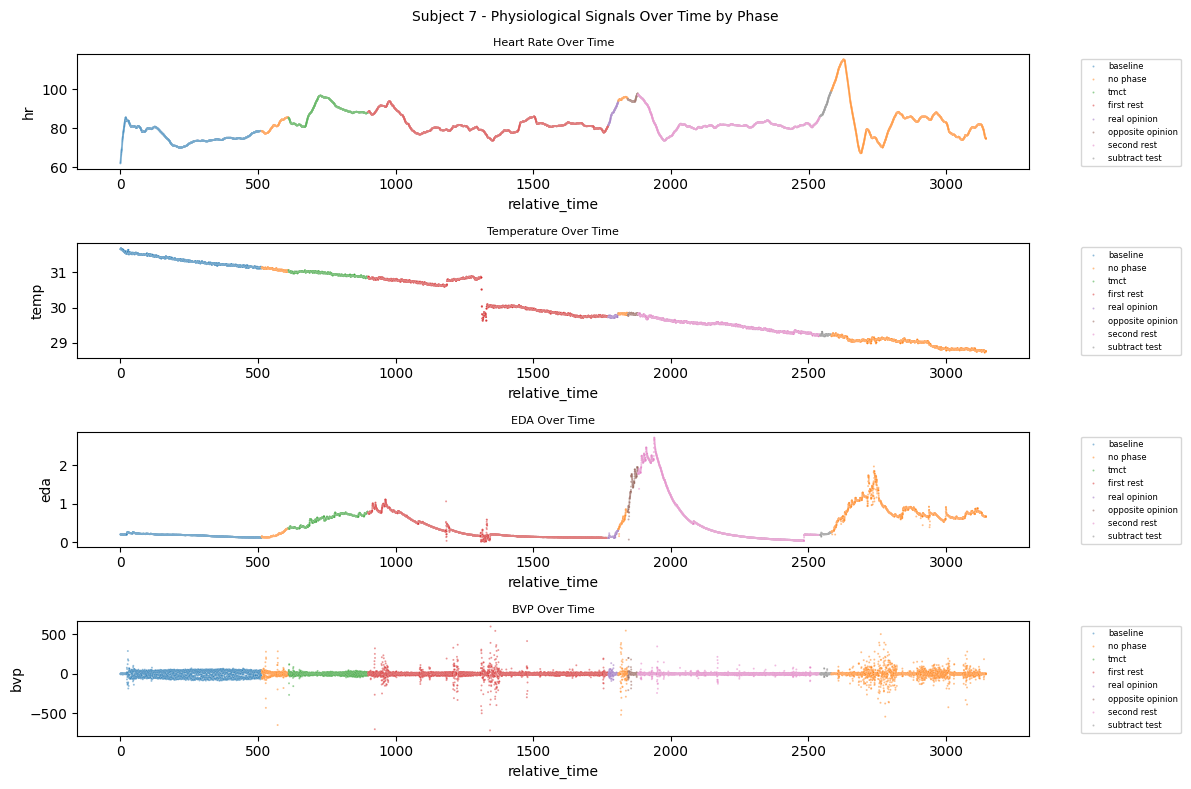

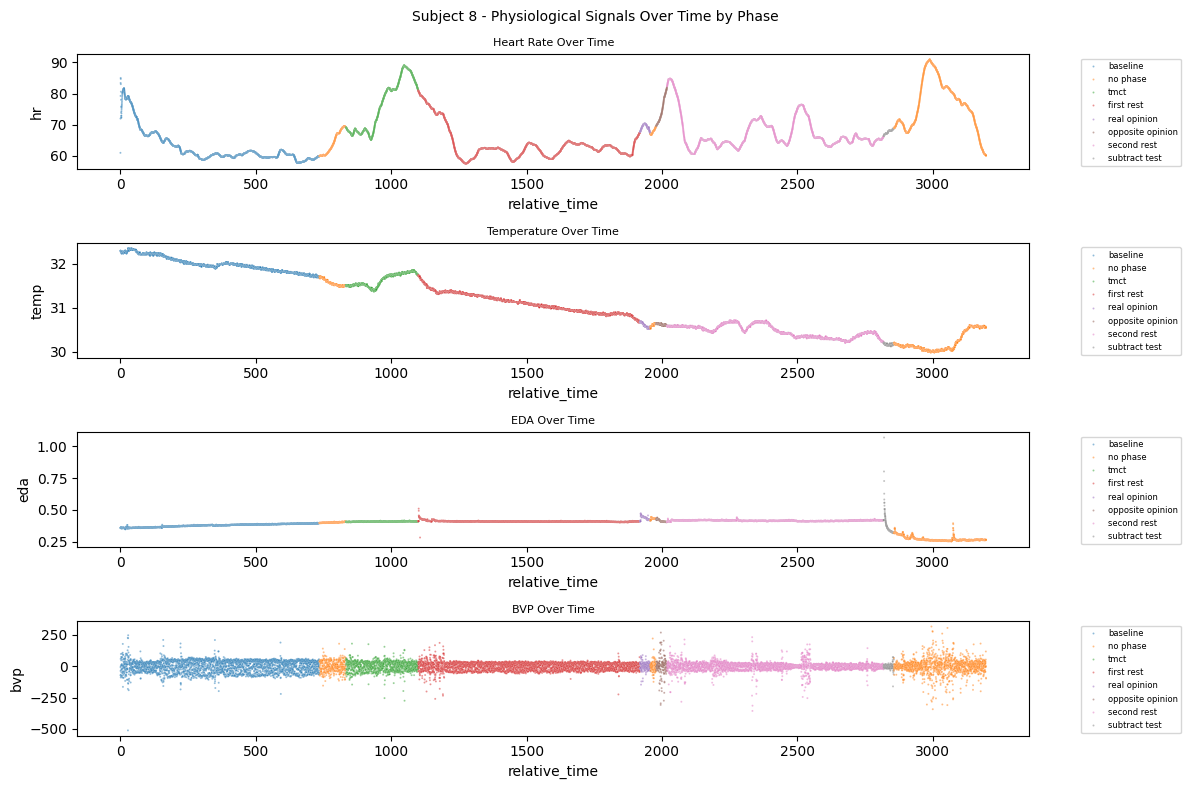

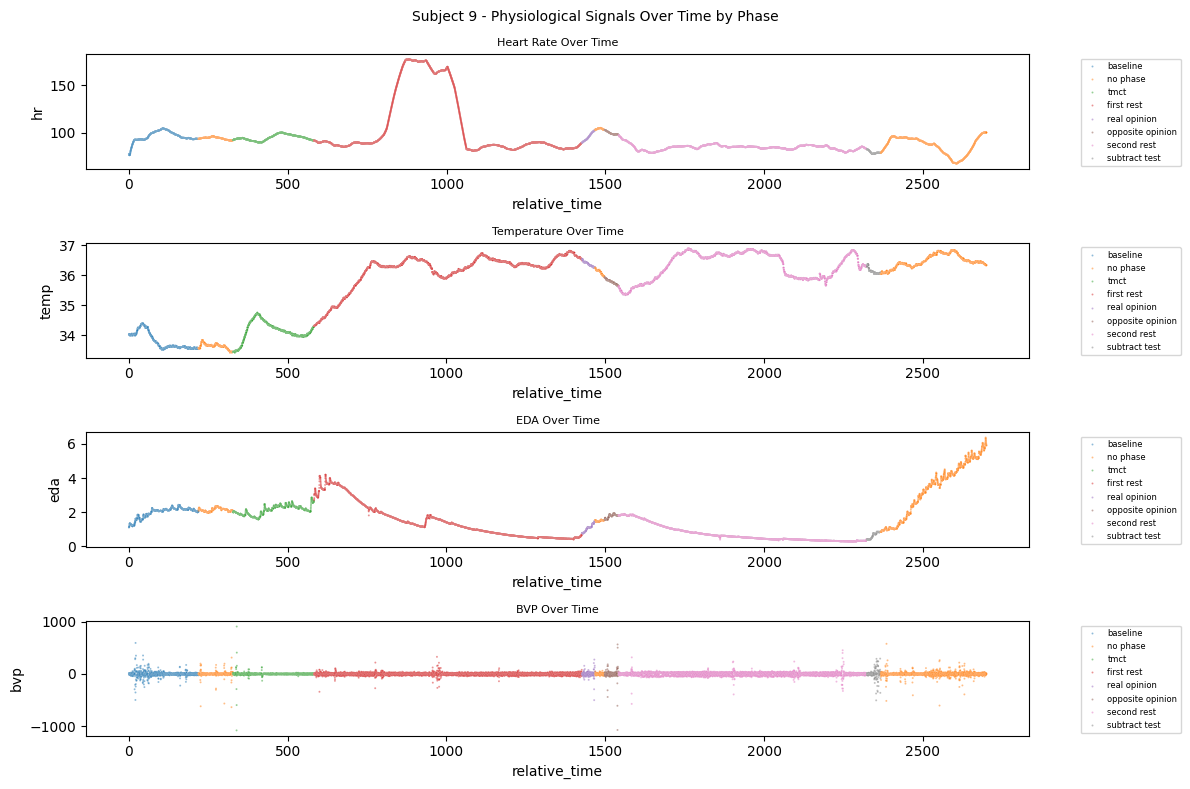

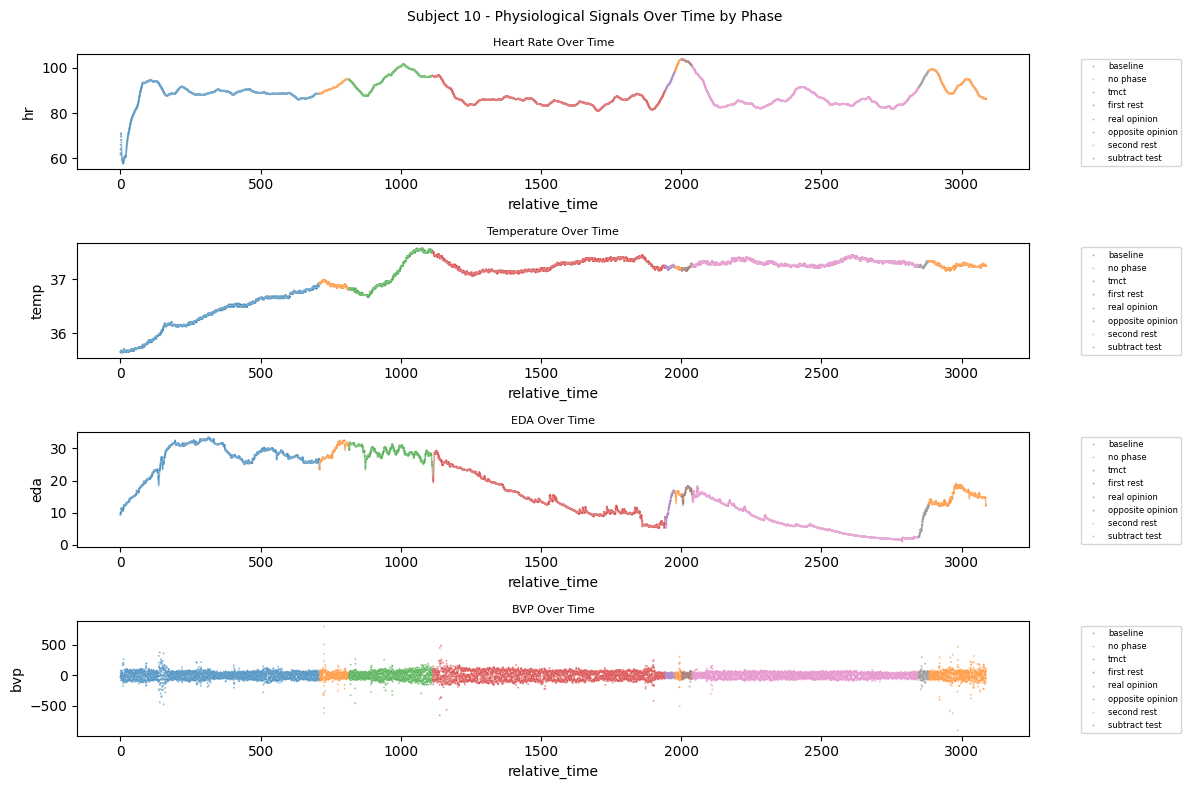

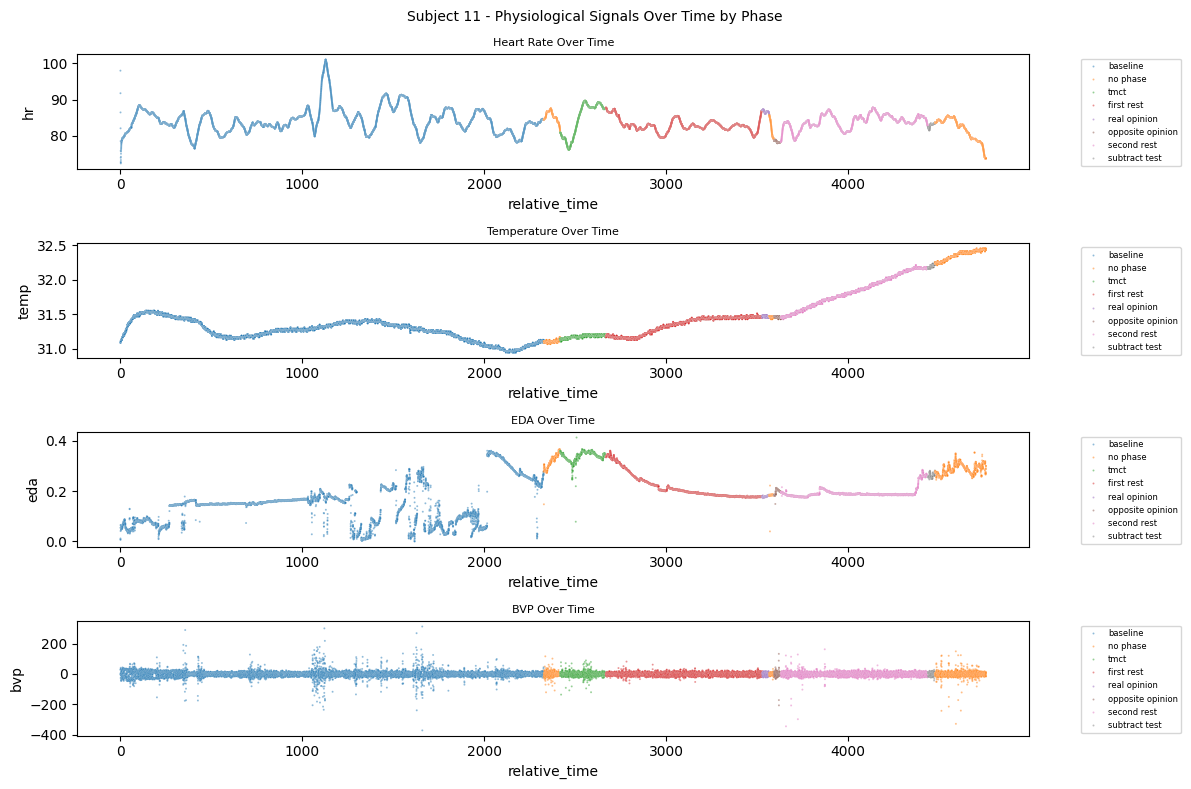

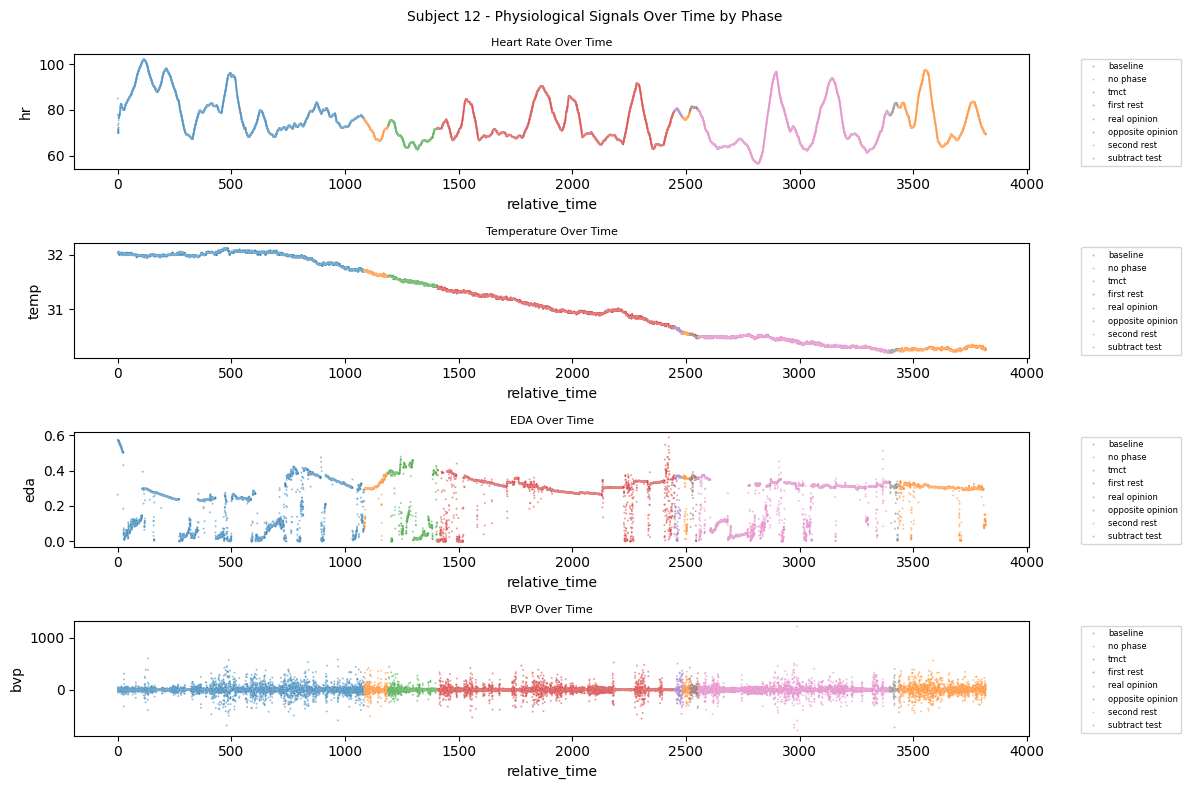

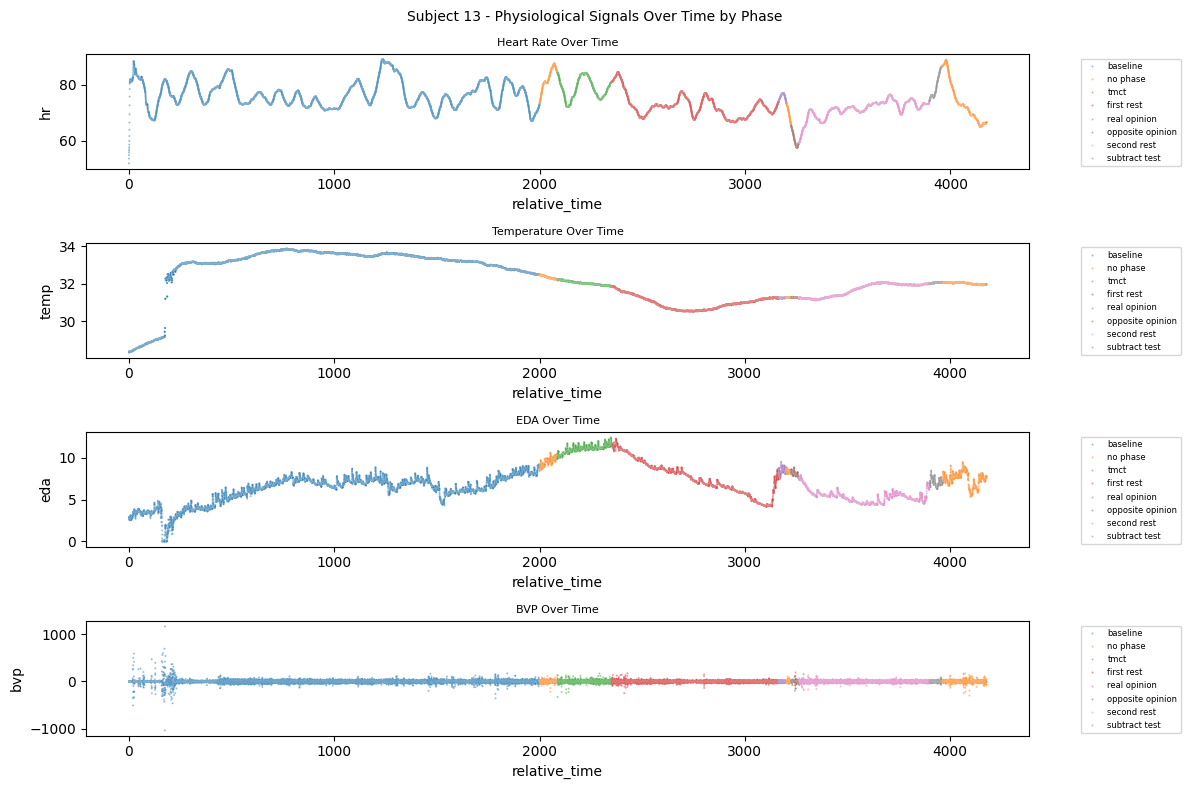

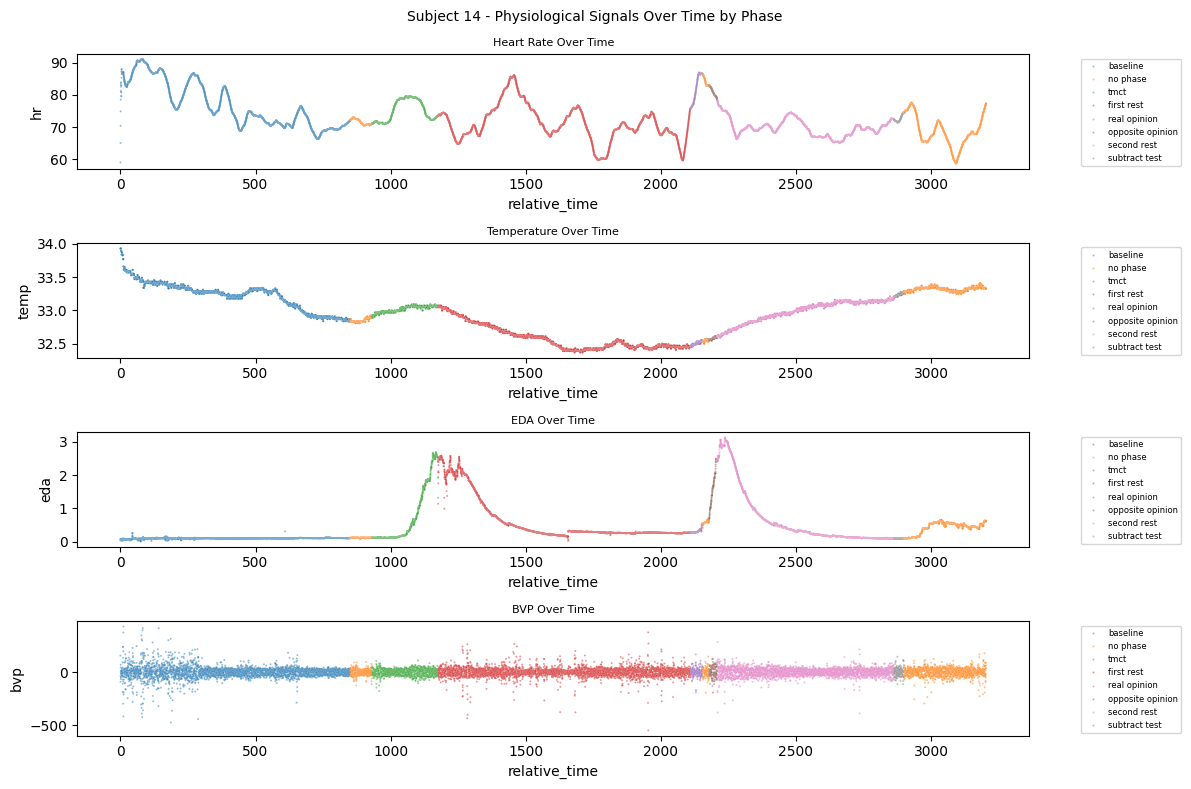

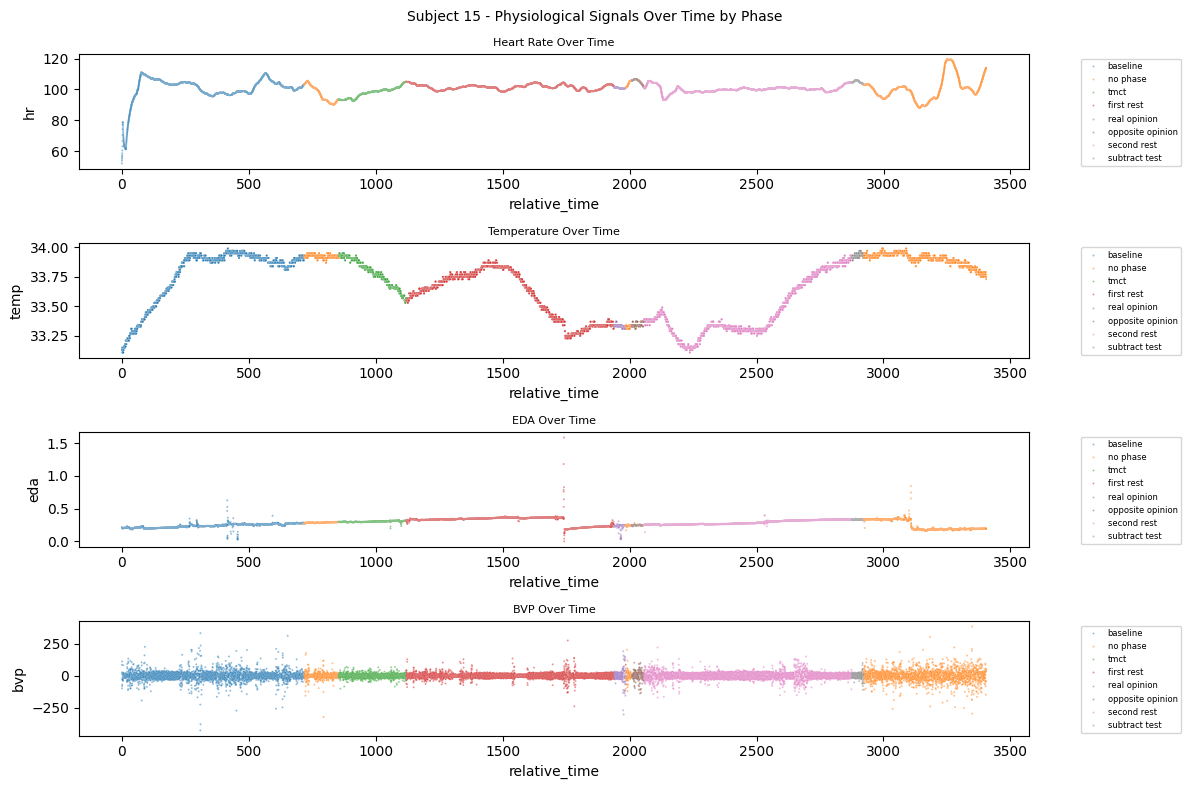

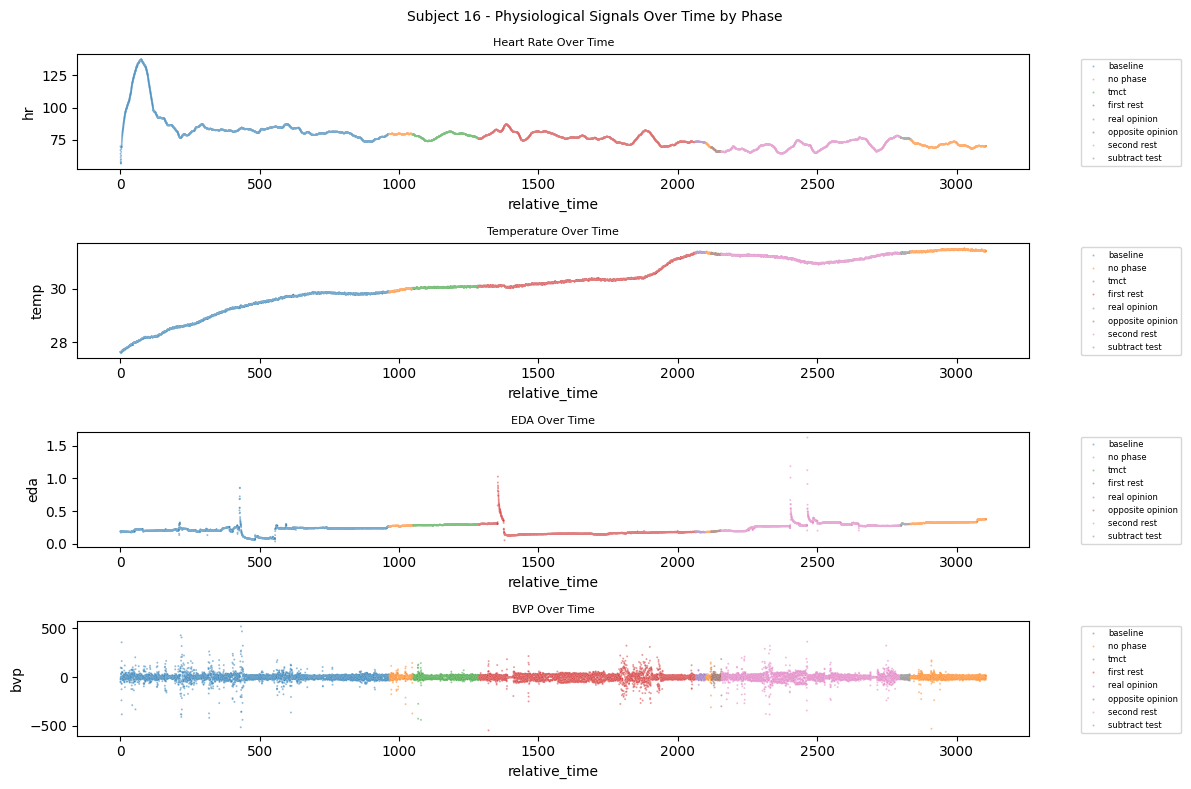

In [73]:
for i, df in enumerate(all_data):
    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Subject {i+1} - Physiological Signals Over Time by Phase', fontsize=10)

    plt.subplot(4, 1, 1)
    sns.scatterplot(data=df, x='relative_time', y='hr', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
    plt.title('Heart Rate Over Time', fontsize=8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

    plt.subplot(4, 1, 2)
    sns.scatterplot(data=df, x='relative_time', y='temp', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
    plt.title('Temperature Over Time', fontsize=8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

    plt.subplot(4, 1, 3)
    sns.scatterplot(data=df, x='relative_time', y='eda', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
    plt.title('EDA Over Time', fontsize=8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

    plt.subplot(4, 1, 4)
    sns.scatterplot(data=df, x='relative_time', y='bvp', hue='phase', alpha=0.5, s=2, hue_order=df['phase'].unique())
    plt.title('BVP Over Time', fontsize=8)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

    plt.tight_layout()
    plt.show()

In [67]:
# Calculate baseline statistics with outlier removal for each signal and subject
baseline_stats = {}

for file_data, file_path in zip(all_data, data_files):
    # Get filename for identifying subject
    filename = file_path.split('/')[-1].split('.')[0].replace('data\\', '')
    
    # Get baseline data
    baseline_data = file_data[file_data['phase'] == 'baseline']
    
    if not baseline_data.empty:
        baseline_stats[filename] = {}
        
        for signal in signals:
            # Calculate quartiles for outlier detection
            Q1 = baseline_data[signal].quantile(0.25)
            Q3 = baseline_data[signal].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define outlier bounds
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Remove outliers
            clean_baseline = baseline_data[
                (baseline_data[signal] >= lower_bound) & 
                (baseline_data[signal] <= upper_bound)
            ]
            
            # Store cleaned baseline statistics
            baseline_stats[filename][signal] = {
                'mean': clean_baseline[signal].mean(),
                'std': clean_baseline[signal].std(),
                'median': clean_baseline[signal].median()
            }

# Create lists to store data for DataFrame
subjects = []
signals_list = []
means = []
stds = []
medians = []

# Populate lists from baseline_stats dictionary
for subject in baseline_stats:
    for signal in baseline_stats[subject]:
        subjects.append(subject)
        signals_list.append(signal)
        means.append(baseline_stats[subject][signal]['mean'])
        stds.append(baseline_stats[subject][signal]['std']) 
        medians.append(baseline_stats[subject][signal]['median'])

# Create DataFrame
baseline_df = pd.DataFrame({
    'subject': subjects,
    'signal': signals_list,
    'mean': means,
    'std': stds,
    'median': medians
})

baseline_df[baseline_df['subject'] == 'f01']

,subject,signal,mean,std,median
0,f01,hr,71.145228,2.421028,70.345000
1,f01,temp,29.982285,0.141176,29.950000
2,f01,eda,0.180036,0.042360,0.157795
3,f01,bvp,-0.366490,19.668966,1.307187


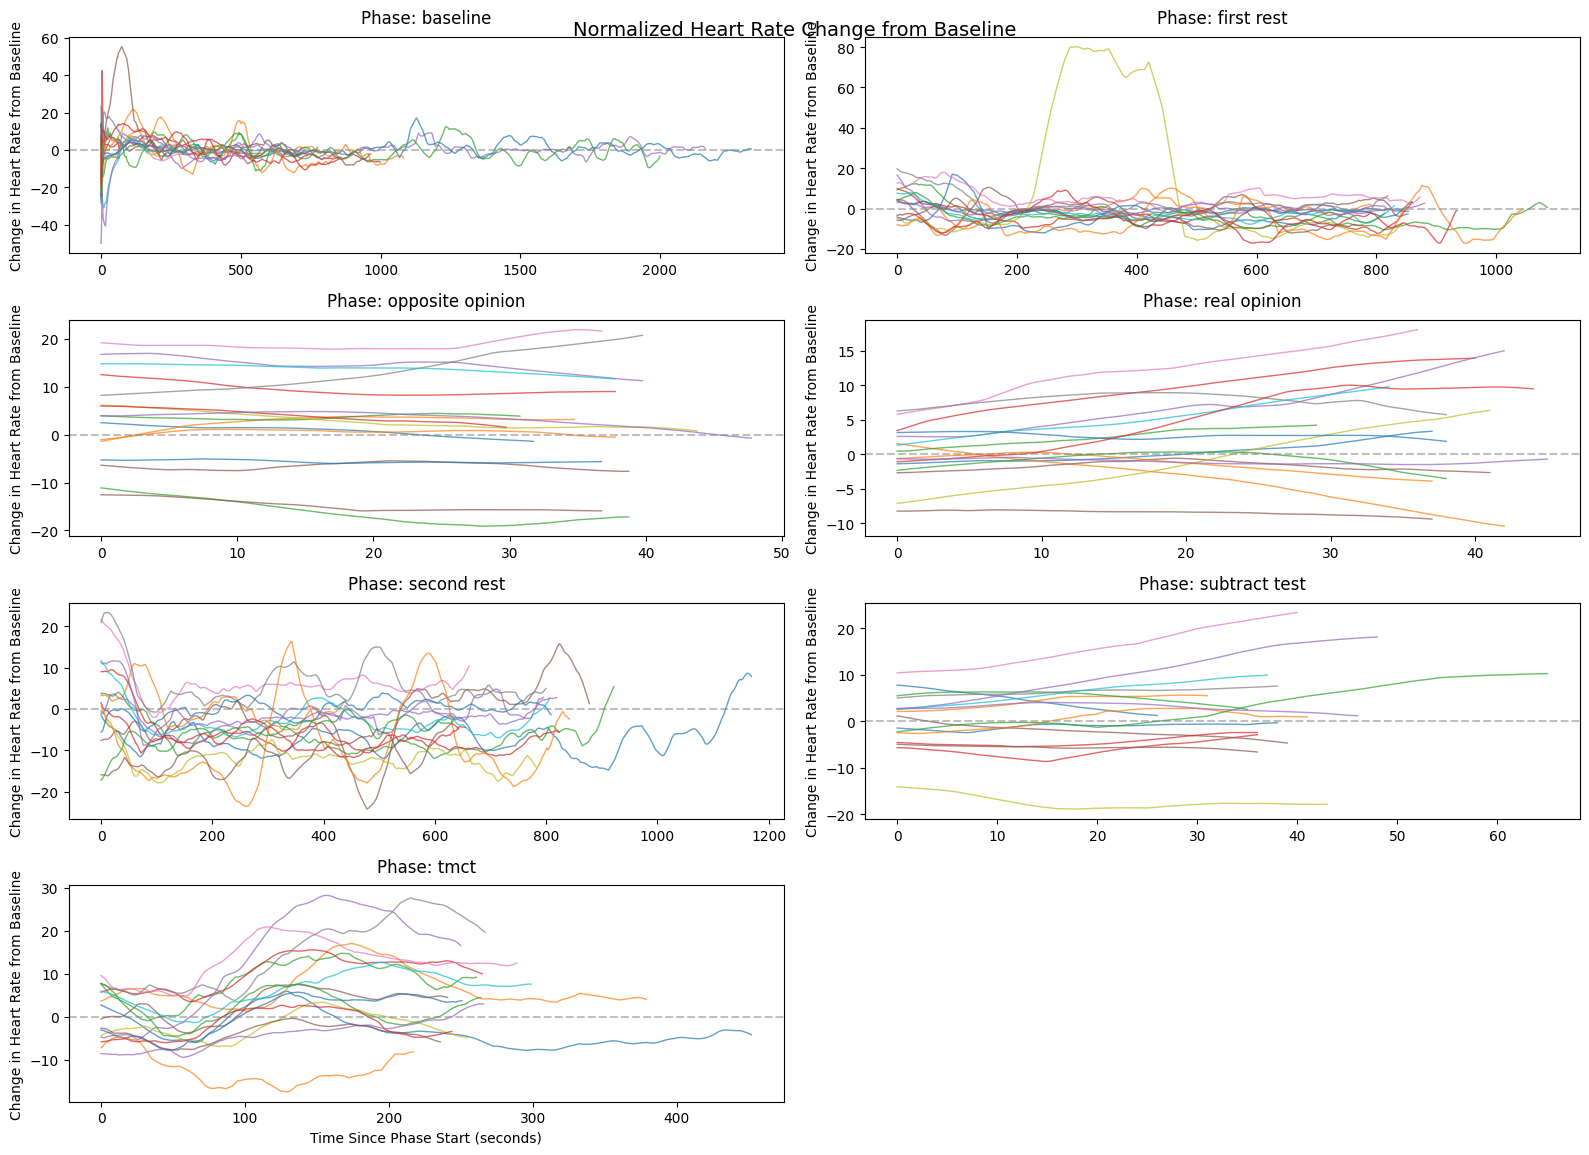

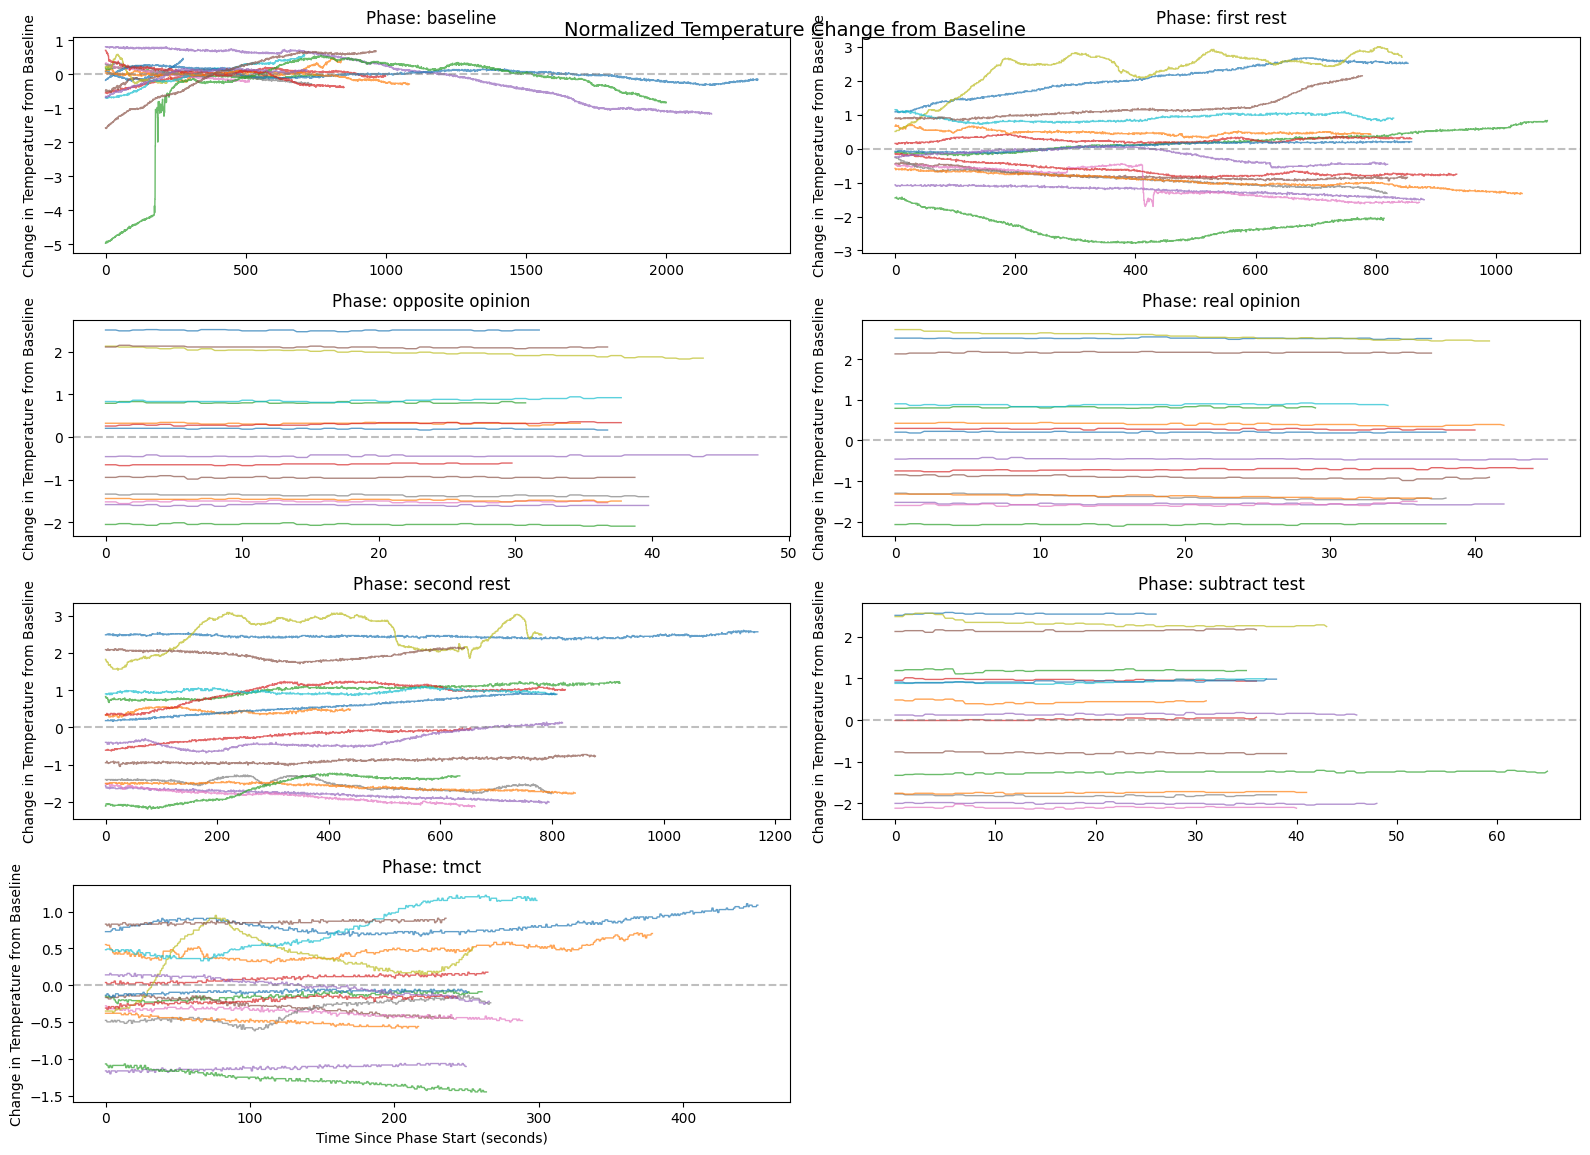

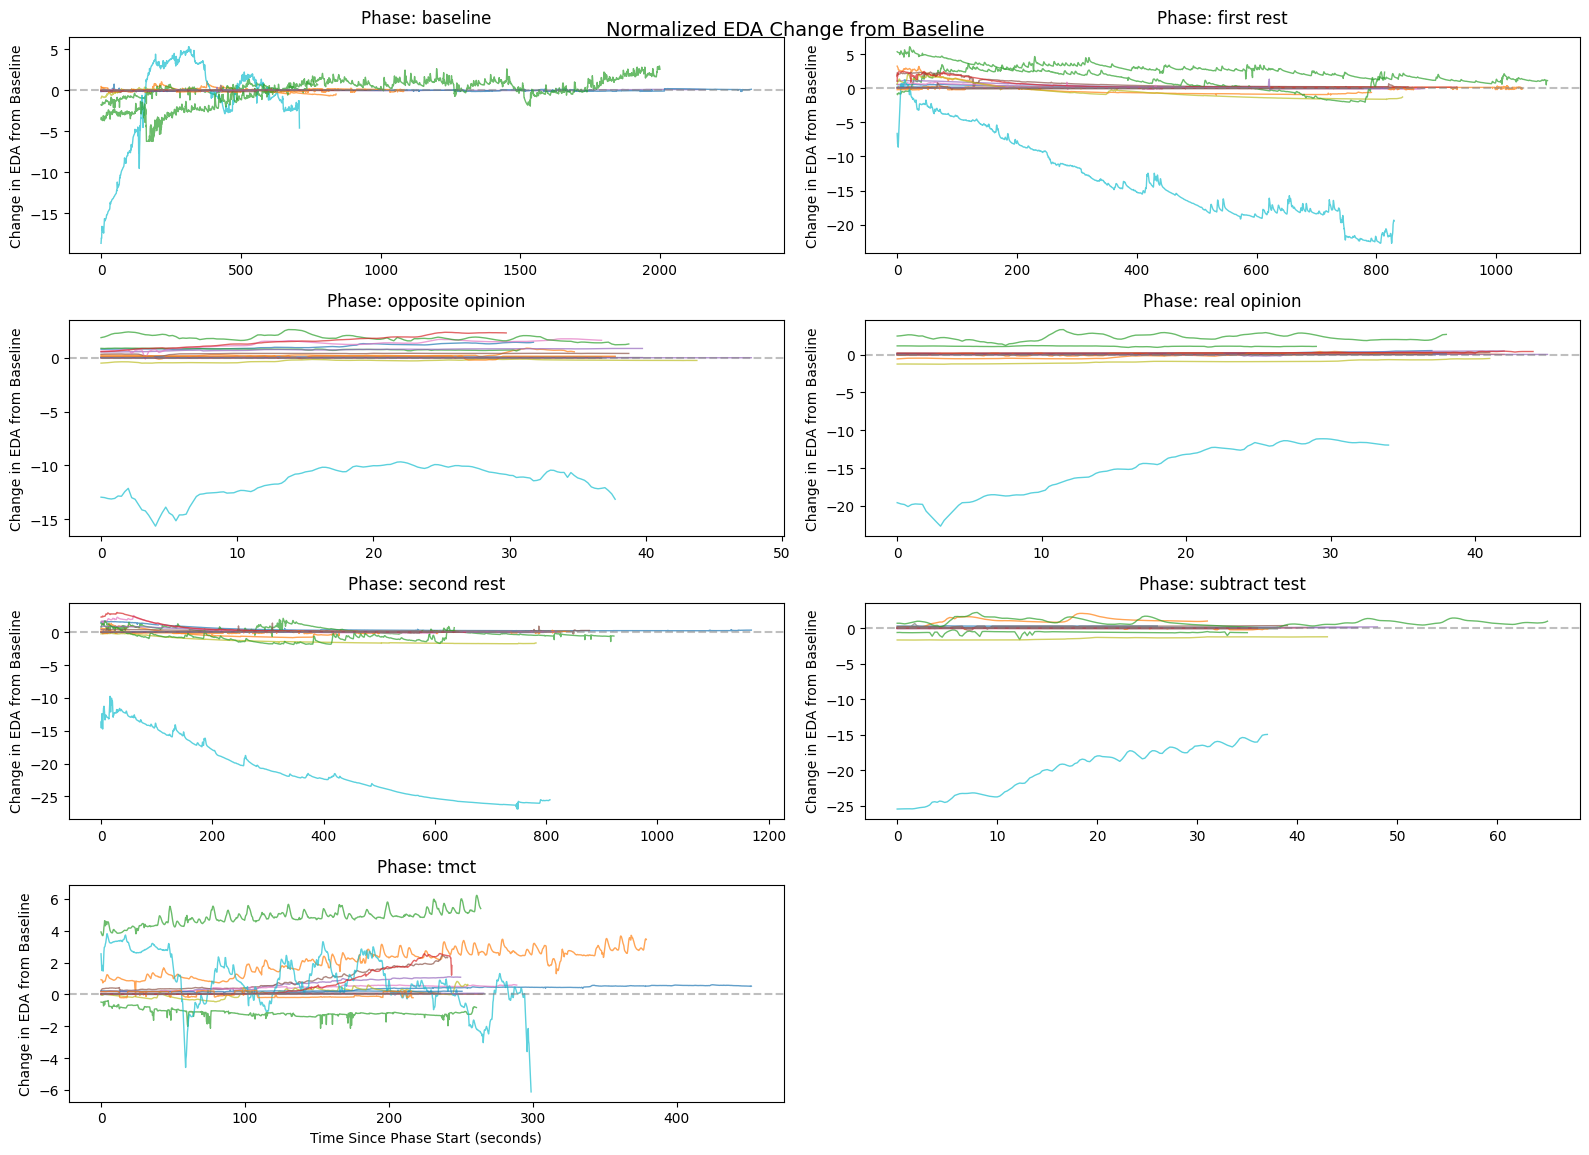

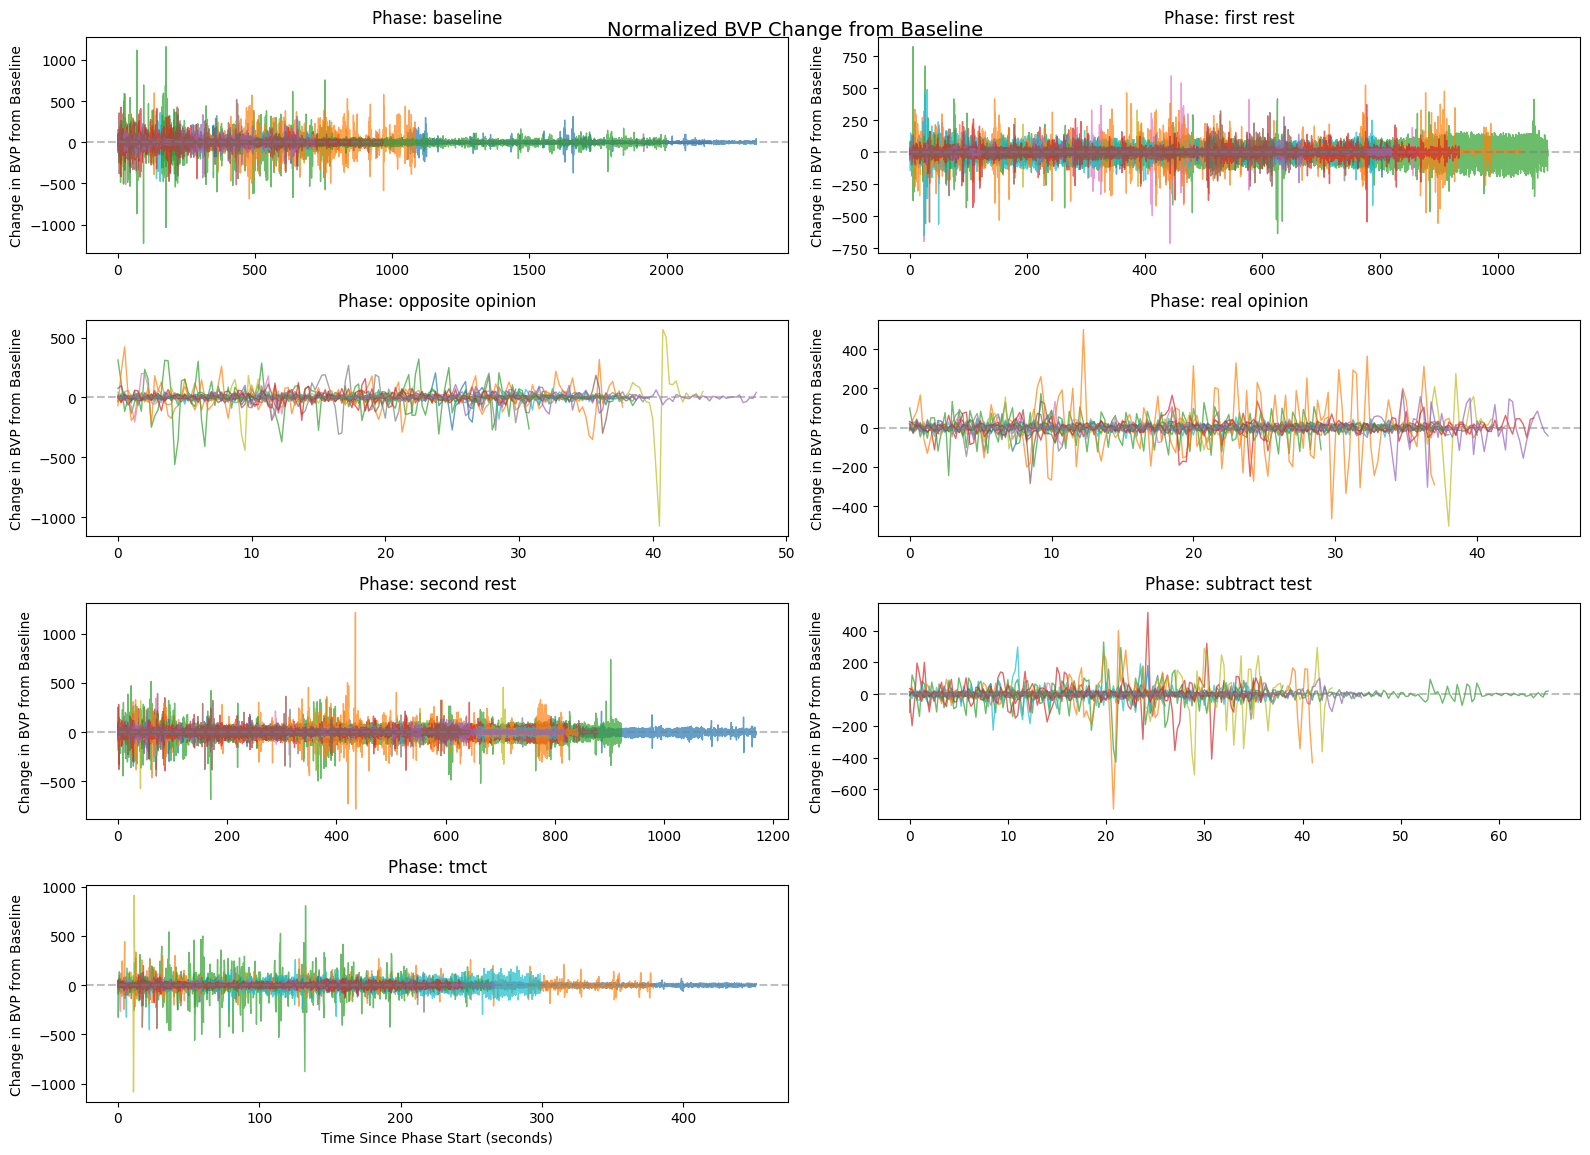

In [ ]:
# Create separate figures for each physiological signal
signals = ['hr', 'temp', 'eda', 'bvp']
signal_names = ['Heart Rate', 'Temperature', 'EDA', 'BVP']

for signal, signal_name in zip(signals, signal_names):
    # Get unique phases excluding 'no phase'
    phases = sorted([p for p in combined_data['phase'].unique() if p != 'no phase' and pd.notna(p)])
    
    # Create subplot for each phase
    plt.figure(figsize=(16, 12))  # Increased figure size
    plt.suptitle(f'Normalized {signal_name} Change from Baseline', fontsize=14, y=0.95)  # Adjusted title position
    
    for i, phase in enumerate(phases, 1):
        ax = plt.subplot(4, 2, i)
        
        # Get data for this phase
        phase_data = combined_data[combined_data['phase'] == phase]
        
        # Plot each individual's data as a separate line
        for file_data, file_path in zip(all_data, data_files):
            file_phase_data = file_data[file_data['phase'] == phase]
            if not file_phase_data.empty:
                # Reset relative time to start at 0 for this phase
                phase_start_time = file_phase_data['relative_time'].min()
                aligned_time = file_phase_data['relative_time'] - phase_start_time
                
                # Get subject ID from filename
                filename = file_path.split('/')[-1].split('.')[0].replace('data\\', '')
                
                # Get baseline statistics for this subject and signal
                subject_baseline = baseline_stats[filename][signal]['mean']
                
                # Calculate change from baseline
                normalized_values = file_phase_data[signal] - subject_baseline
                
                plt.plot(aligned_time, 
                        normalized_values,
                        alpha=0.7, 
                        linewidth=1)
        
        plt.title(f'Phase: {phase}', fontsize=12, pad=10)
        plt.ylabel(f'Change in {signal_name} from Baseline', fontsize=10)
        plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)  # Add reference line at 0
        if i > 6:  # Only show x-label for bottom row
            plt.xlabel('Time Since Phase Start (seconds)', fontsize=10)
    
    plt.tight_layout()
    plt.show()



Summary Statistics of Stress Level Changes from Baseline:
      TMCT  First Rest  Real Opinion  Opposite Opinion  Second Rest  Subtract
mean  3.11       -0.67          0.28              0.89        -0.89      1.28
std   2.03        1.78          1.64              1.94         1.53      2.19
min   1.00       -4.00         -2.00             -1.00        -4.00     -1.00
max   7.00        3.00          5.00              6.00         3.00      8.00

Percentage of Participants Reporting Increased Stress:
TMCT: 100.0%
First Rest: 27.8%
Real Opinion: 38.9%
Opposite Opinion: 38.9%
Second Rest: 11.1%
Subtract: 55.6%


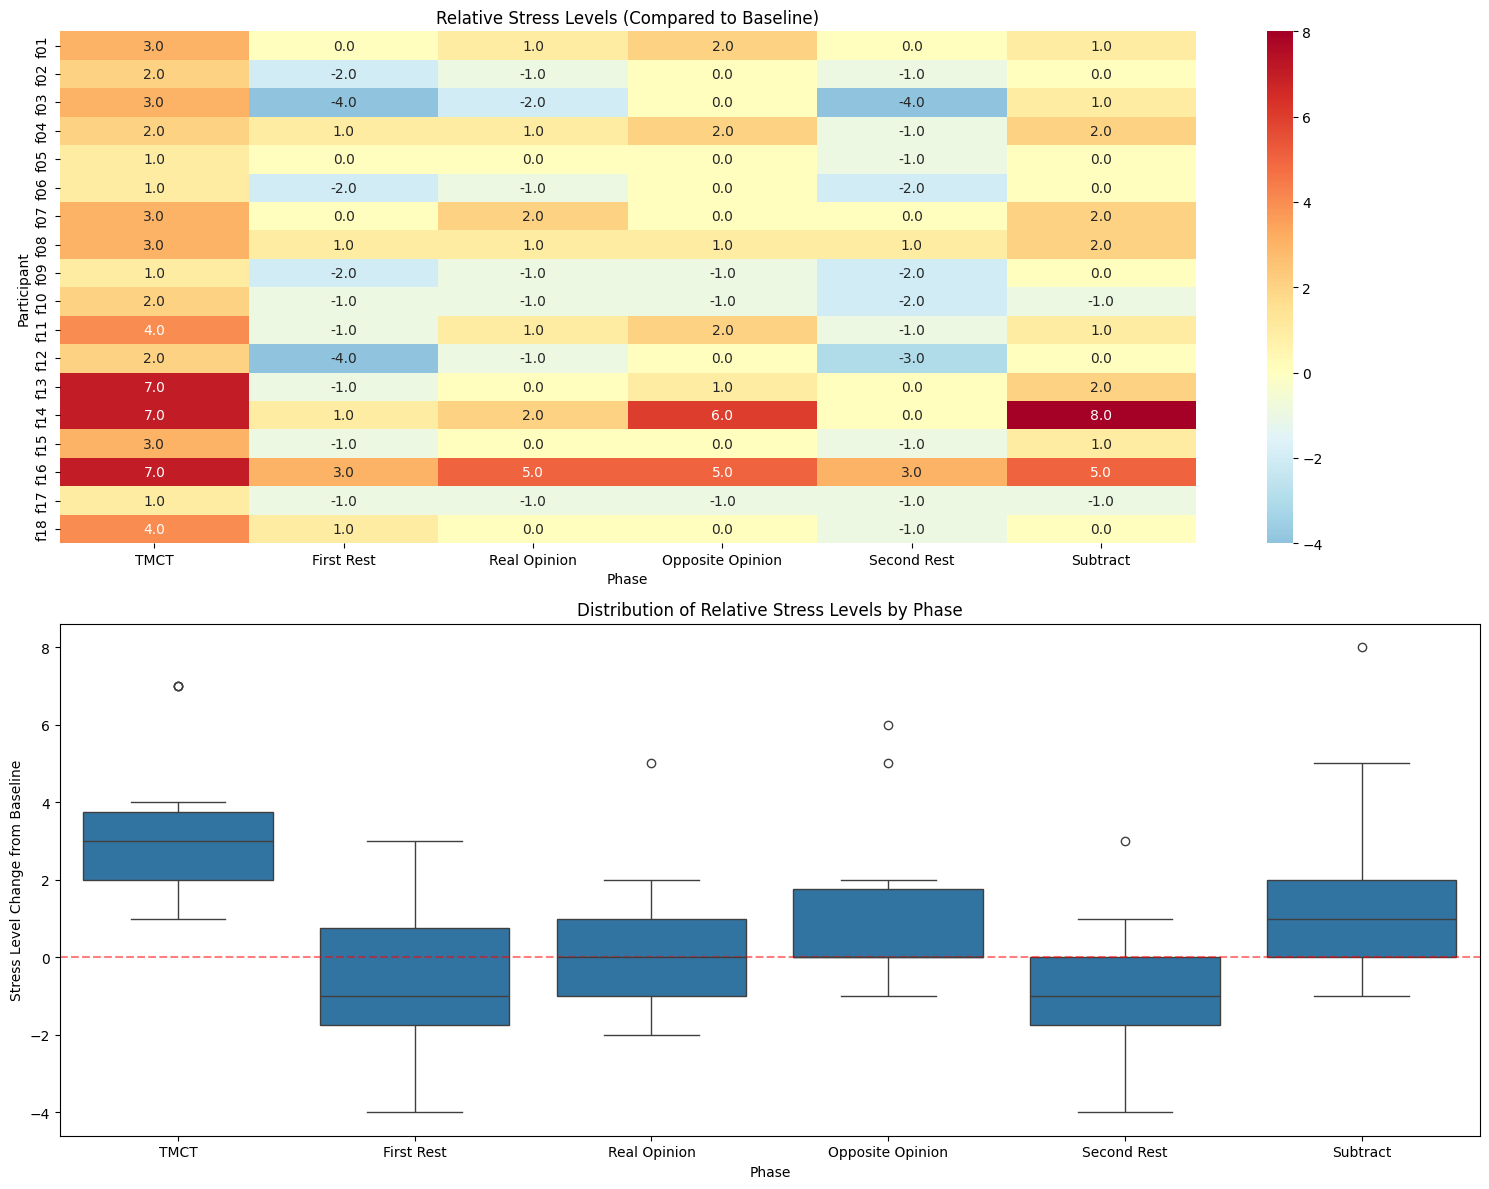

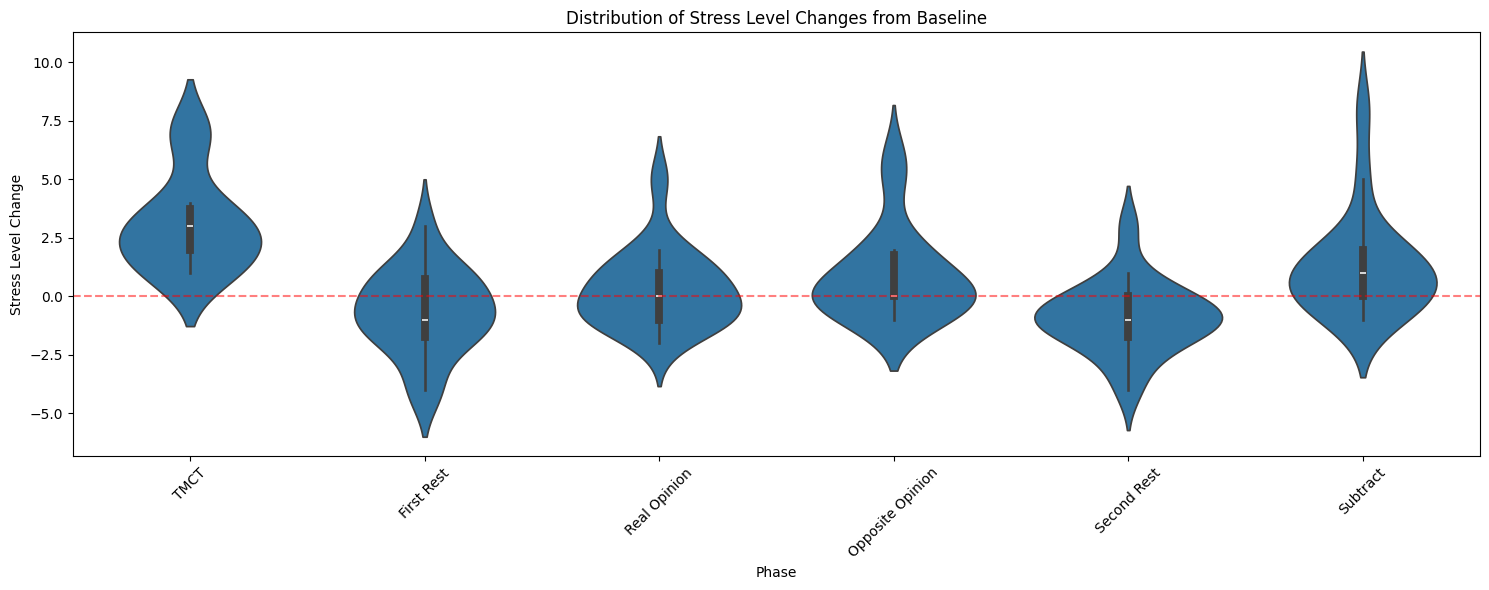

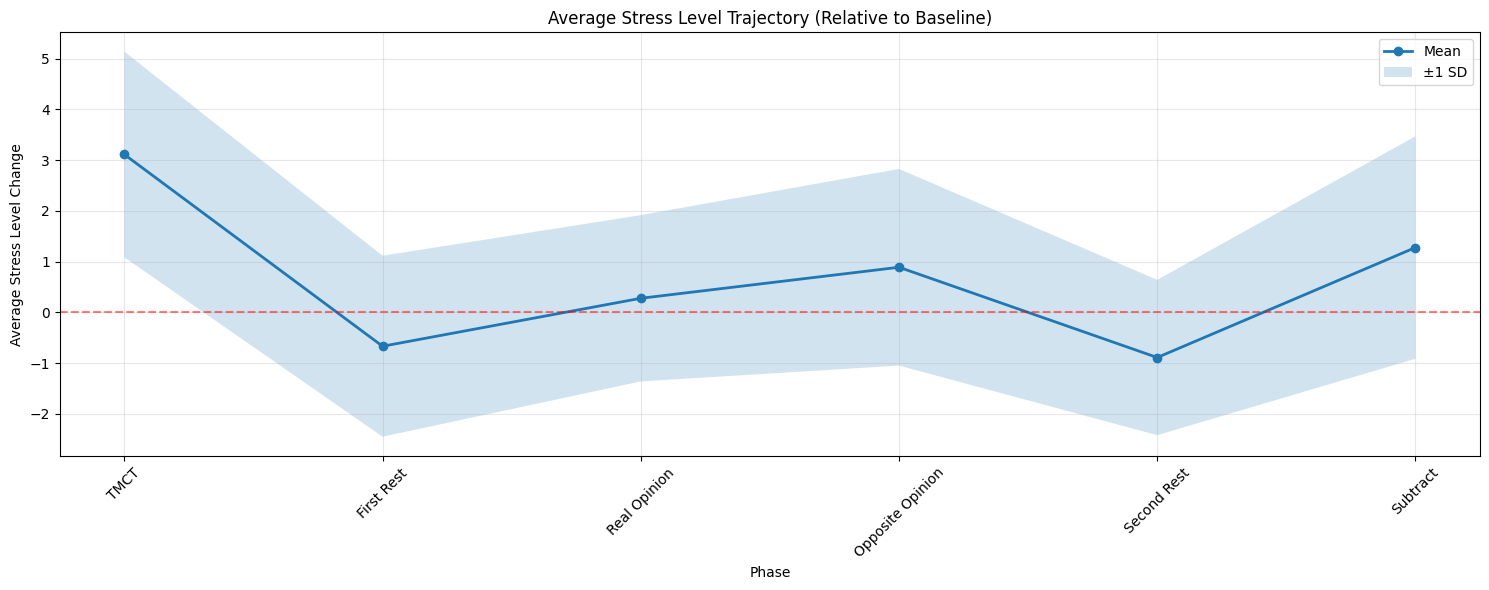

In [75]:
# Read the stress level data
stress_data = pd.read_csv('../original/Stress_Level_V2.csv', index_col=0)

# Calculate relative stress levels by subtracting baseline from each phase
baseline_values = stress_data['Baseline']
relative_stress = stress_data.copy()

for column in stress_data.columns:
    relative_stress[column] = stress_data[column] - baseline_values

# Drop the Baseline column since it will be all zeros
relative_stress = relative_stress.drop('Baseline', axis=1)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Heatmap of relative stress levels
sns.heatmap(relative_stress, 
            cmap='RdYlBu_r',
            center=0,
            annot=True,
            fmt='.1f',
            ax=ax1)
ax1.set_title('Relative Stress Levels (Compared to Baseline)')
ax1.set_xlabel('Phase')
ax1.set_ylabel('Participant')

# Plot 2: Box plot of relative stress levels
relative_stress_melted = relative_stress.melt()
sns.boxplot(data=relative_stress_melted, 
            x='variable',
            y='value',
            ax=ax2)
ax2.set_title('Distribution of Relative Stress Levels by Phase')
ax2.set_xlabel('Phase')
ax2.set_ylabel('Stress Level Change from Baseline')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Add summary statistics
phase_stats = relative_stress.agg(['mean', 'std', 'min', 'max']).round(2)
print("\nSummary Statistics of Stress Level Changes from Baseline:")
print(phase_stats)

# Calculate the percentage of participants who reported increased stress in each phase
increased_stress = (relative_stress > 0).mean() * 100
print("\nPercentage of Participants Reporting Increased Stress:")
for phase, percentage in increased_stress.items():
    print(f"{phase}: {percentage:.1f}%")

plt.tight_layout()
plt.show()

# Create violin plots to show the distribution of stress changes
plt.figure(figsize=(15, 6))
sns.violinplot(data=relative_stress_melted, x='variable', y='value')
plt.title('Distribution of Stress Level Changes from Baseline')
plt.xlabel('Phase')
plt.ylabel('Stress Level Change')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate and plot average stress trajectory
plt.figure(figsize=(15, 6))
mean_stress = relative_stress.mean()
std_stress = relative_stress.std()

plt.plot(mean_stress.index, mean_stress.values, marker='o', linewidth=2, label='Mean')
plt.fill_between(mean_stress.index, 
                 mean_stress.values - std_stress.values,
                 mean_stress.values + std_stress.values,
                 alpha=0.2,
                 label='±1 SD')

plt.title('Average Stress Level Trajectory (Relative to Baseline)')
plt.xlabel('Phase')
plt.ylabel('Average Stress Level Change')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()